<a href="https://colab.research.google.com/github/seulkong/karpathy_study/blob/main/chapter6_correlation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 6: Do Two Variables Move Together?

**Genomics Statistics Tutorial - Python**

In this notebook, you'll learn:
- **Understand correlation through scatter plots (descriptive statistics first!)**
- **Choose between Pearson and Spearman based on relationship type**
- Recognize when data visualization is more important than cutoffs
- Handle outliers in omics data
- Understand why correlation ≠ causation

---

## Setup: Install and Load Packages

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
from scipy.interpolate import make_interp_spline
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Packages loaded successfully!")

✓ Packages loaded successfully!


---

## Biological Question

You're studying gene regulation and measured expression of two genes across 50 tissue samples:
- **BDNF** (Brain-Derived Neurotrophic Factor): promotes neuronal growth
- **NTRK2** (receptor for BDNF): binds to BDNF

**The key question: "If BDNF expression is high, is NTRK2 expression also high?"**

This is asking about **correlation** - whether two variables move together.

**Other examples:**
- Protein expression vs mRNA expression
- Gene expression vs phenotype score
- Methylation level vs gene expression

---

## Part 1: ALWAYS Plot Your Data First (Descriptive Statistics)

**Never calculate correlation before looking at your data!**

Scatter plots reveal:
- Type of relationship (linear? curved? none?)
- Presence of outliers
- Data distribution
- Whether correlation is even appropriate

### Generate Sample Data

In [ ]:
# Set seed for reproducibility
np.random.seed(123)
n_samples = 50

# Generate correlated gene expression data
BDNF_expr = np.random.normal(loc=8, scale=1.5, size=n_samples)
NTRK2_expr = BDNF_expr * 0.75 + np.random.normal(loc=1.5, scale=0.8, size=n_samples)

data = pd.DataFrame({
    'sample_id': [f'Sample_{i}' for i in range(1, n_samples + 1)],
    'BDNF': BDNF_expr,
    'NTRK2': NTRK2_expr
})

print("Sample Data (first 6 rows):")
print(data.head(6))

Sample Data (first 6 rows):
  sample_id       BDNF      NTRK2
0  Sample_1   6.371554   5.243397
1  Sample_2   9.496018   7.790983
2  Sample_3   8.424468   9.213321
3  Sample_4   5.740558   5.166968
4  Sample_5   7.132100   6.872821
5  Sample_6  10.477155  10.213319


### Visualization 1: Basic Scatter Plot

**This is THE most important plot for correlation analysis.**

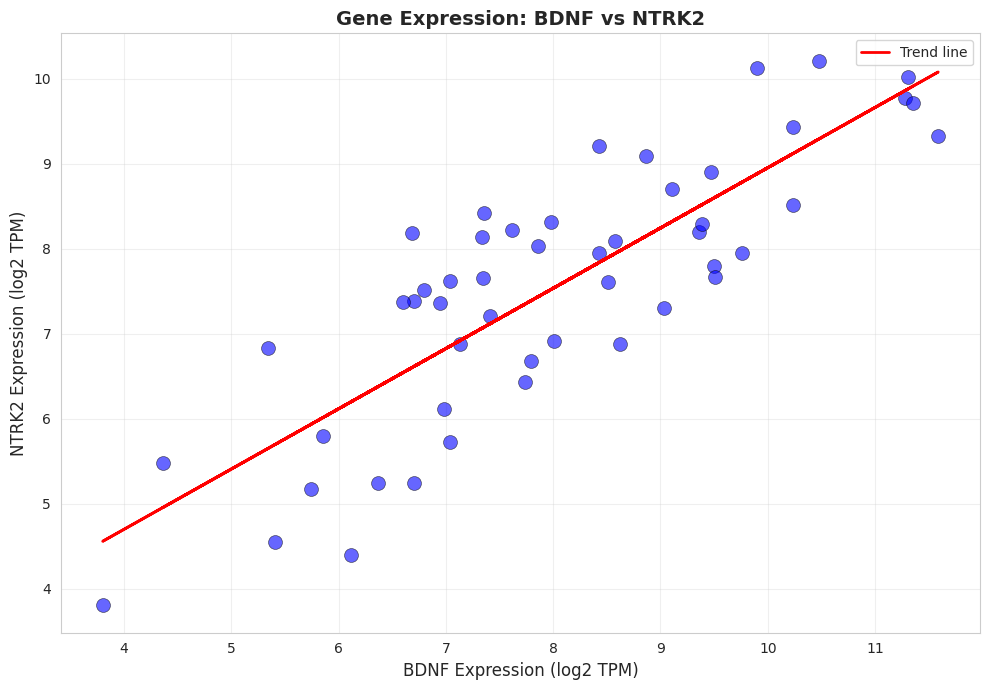


💡 What to look for in scatter plots:
   • Do points follow a pattern?
   • Is the pattern linear (straight line)?
   • Or non-linear (curved)?
   • Are there any outliers (far from pattern)?
   • How tight is the relationship?


In [ ]:
# Create scatter plot
plt.figure(figsize=(10, 7))
plt.scatter(data['BDNF'], data['NTRK2'],
           alpha=0.6, s=100, color='blue', edgecolors='black', linewidth=0.5)

# Add trend line
z = np.polyfit(data['BDNF'], data['NTRK2'], 1)
p = np.poly1d(z)
plt.plot(data['BDNF'], p(data['BDNF']), "r-", linewidth=2, label='Trend line')

plt.title('Gene Expression: BDNF vs NTRK2', fontsize=14, fontweight='bold')
plt.xlabel('BDNF Expression (log2 TPM)', fontsize=12)
plt.ylabel('NTRK2 Expression (log2 TPM)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 What to look for in scatter plots:")
print("   • Do points follow a pattern?")
print("   • Is the pattern linear (straight line)?")
print("   • Or non-linear (curved)?")
print("   • Are there any outliers (far from pattern)?")
print("   • How tight is the relationship?")

---

## Part 2: Understanding Different Relationship Types

### Scenario 1: Linear Relationship (Perfect for Pearson)

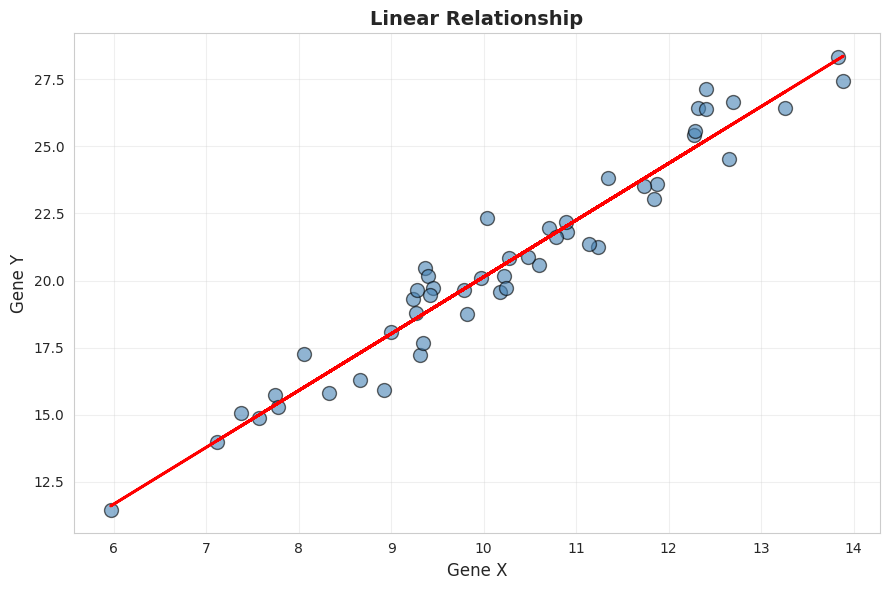


→ Points follow a STRAIGHT LINE
→ This is perfect for Pearson correlation


In [ ]:
# Linear relationship
np.random.seed(456)
x_linear = np.random.normal(10, 2, 50)
y_linear = 2 * x_linear + np.random.normal(0, 1, 50)  # y = 2x + noise

plt.figure(figsize=(9, 6))
plt.scatter(x_linear, y_linear, alpha=0.6, s=100, color='steelblue', edgecolors='black')

# Add trend line
z = np.polyfit(x_linear, y_linear, 1)
p = np.poly1d(z)
plt.plot(x_linear, p(x_linear), "r-", linewidth=2)

plt.title('Linear Relationship', fontsize=14, fontweight='bold')
plt.xlabel('Gene X', fontsize=12)
plt.ylabel('Gene Y', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n→ Points follow a STRAIGHT LINE")
print("→ This is perfect for Pearson correlation")

### Scenario 2: Monotonic (Non-Linear) Relationship

**Monotonic:** Always increasing (or always decreasing), but not in a straight line.

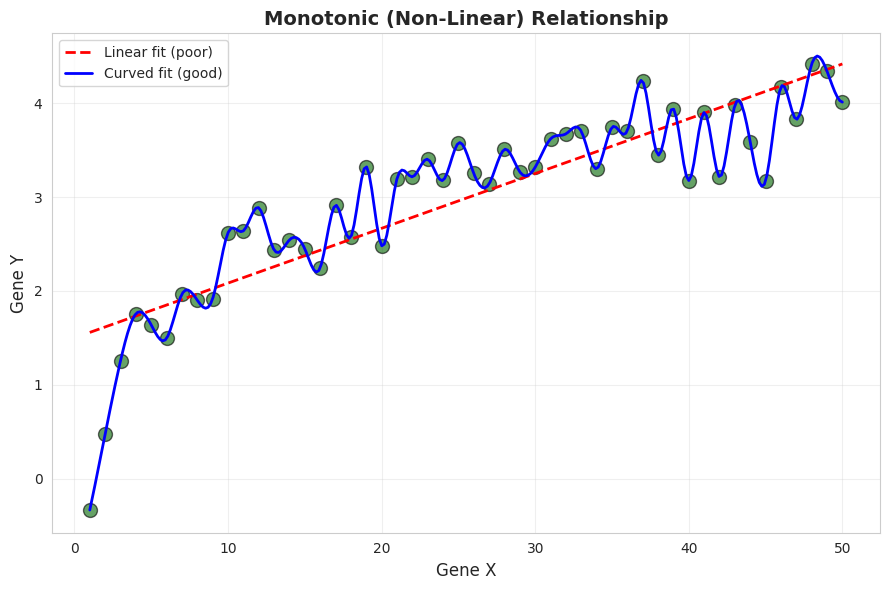


→ Relationship is CURVED, not straight
→ But still consistently increasing
→ Spearman is better than Pearson here


In [ ]:
# Monotonic but non-linear relationship (logarithmic)
np.random.seed(789)
x_mono = np.linspace(1, 50, 50)
y_mono = np.log(x_mono) + np.random.normal(0, 0.3, 50)

plt.figure(figsize=(9, 6))
plt.scatter(x_mono, y_mono, alpha=0.6, s=100, color='darkgreen', edgecolors='black')

# Add linear fit (poor)
z = np.polyfit(x_mono, y_mono, 1)
p = np.poly1d(z)
plt.plot(x_mono, p(x_mono), "r--", linewidth=2, label='Linear fit (poor)')

# Add curved fit (good)
x_smooth = np.linspace(x_mono.min(), x_mono.max(), 300)
spl = make_interp_spline(x_mono, y_mono, k=3)
y_smooth = spl(x_smooth)
plt.plot(x_smooth, y_smooth, 'b-', linewidth=2, label='Curved fit (good)')

plt.title('Monotonic (Non-Linear) Relationship', fontsize=14, fontweight='bold')
plt.xlabel('Gene X', fontsize=12)
plt.ylabel('Gene Y', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n→ Relationship is CURVED, not straight")
print("→ But still consistently increasing")
print("→ Spearman is better than Pearson here")

### Scenario 3: Outliers Can Mislead

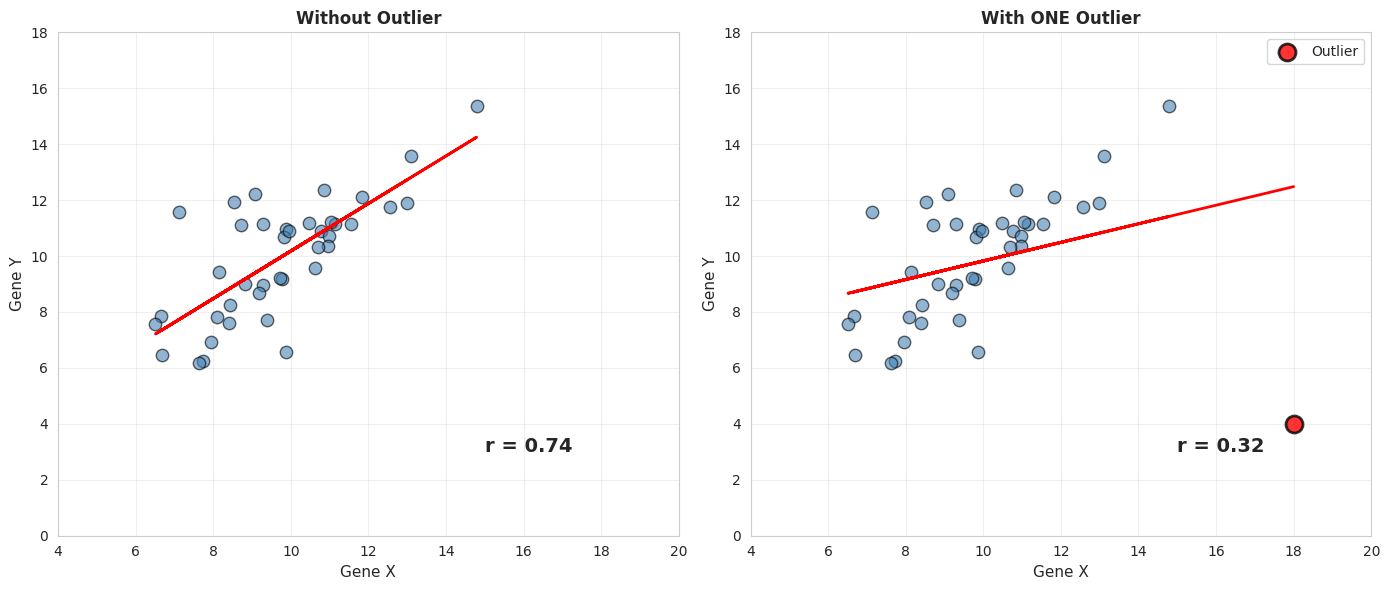


⚠️ ONE outlier changed r from 0.74 to 0.32
→ This is why we MUST plot data!
→ Spearman is more robust to outliers


In [ ]:
# Clean data
np.random.seed(111)
x_clean = np.random.normal(10, 2, 40)
y_clean = 0.8 * x_clean + np.random.normal(2, 1.5, 40)

# Add one outlier
x_outlier = np.append(x_clean, 18)
y_outlier = np.append(y_clean, 4)

# Calculate correlations
r_clean, _ = pearsonr(x_clean, y_clean)
r_outlier, _ = pearsonr(x_outlier, y_outlier)

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Without outlier
axes[0].scatter(x_clean, y_clean, alpha=0.6, s=80, color='steelblue', edgecolors='black')
z1 = np.polyfit(x_clean, y_clean, 1)
p1 = np.poly1d(z1)
axes[0].plot(x_clean, p1(x_clean), "r-", linewidth=2)
axes[0].set_title('Without Outlier', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Gene X', fontsize=11)
axes[0].set_ylabel('Gene Y', fontsize=11)
axes[0].set_xlim(4, 20)
axes[0].set_ylim(0, 18)
axes[0].text(15, 3, f'r = {r_clean:.2f}', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# With outlier
axes[1].scatter(x_clean, y_clean, alpha=0.6, s=80, color='steelblue', edgecolors='black')
axes[1].scatter([18], [4], alpha=0.8, s=150, color='red', edgecolors='black', linewidth=2, label='Outlier')
z2 = np.polyfit(x_outlier, y_outlier, 1)
p2 = np.poly1d(z2)
axes[1].plot(x_outlier, p2(x_outlier), "r-", linewidth=2)
axes[1].set_title('With ONE Outlier', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Gene X', fontsize=11)
axes[1].set_ylabel('Gene Y', fontsize=11)
axes[1].set_xlim(4, 20)
axes[1].set_ylim(0, 18)
axes[1].text(15, 3, f'r = {r_outlier:.2f}', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n⚠️ ONE outlier changed r from {r_clean:.2f} to {r_outlier:.2f}")
print("→ This is why we MUST plot data!")
print("→ Spearman is more robust to outliers")

---

## Part 3: Pearson vs Spearman - Decision Guide

### Decision Tree

```
STEP 1: Plot your data (scatter plot)
│
STEP 2: What does the scatter plot show?
│
├─ Linear relationship + No outliers
│   └─ ✓ Use PEARSON
│       • Measures LINEAR association
│       • More powerful when appropriate
│       • Best for: normalized gene expression, proteomics
│
├─ Non-linear BUT monotonic (always increasing/decreasing)
│   └─ ✓ Use SPEARMAN
│       • Measures RANK-ORDER association
│       • Works with any monotonic relationship
│
├─ Outliers present
│   └─ ✓ Use SPEARMAN
│       • Robust to outliers
│       • Based on ranks, not raw values
│
└─ Count data (RNA-seq, ChIP-seq)
    └─ ✓ Use SPEARMAN
        • Count data is typically non-normal
        • Right-skewed distribution
```

### Key Differences

| Aspect | Pearson | Spearman |
|--------|---------|----------|
| **Measures** | Linear relationship | Monotonic (rank-order) relationship |
| **Works on** | Raw values | Ranks |
| **Assumes** | Linear pattern | Only monotonic pattern |
| **Sensitive to** | Outliers (HIGH) | Outliers (LOW) |
| **Best for** | Clean, normalized data | Count data, ordinal data, outliers |
| **Example use** | Log-transformed TPM | Raw RNA-seq counts |
| **Symbol** | r | ρ (rho) |

---

## Part 4: How Spearman Works - Rank Transformation

**Key concept:** Spearman converts values to ranks, making it immune to outliers.

In [ ]:
# Demonstrate rank transformation
example = pd.DataFrame({
    'Sample': ['S1', 'S2', 'S3', 'S4', 'S5', 'S6'],
    'Gene_A': [100, 250, 50, 800, 150, 400],
    'Gene_B': [200, 500, 120, 1500, 350, 750]
})

# Add ranks
example['Gene_A_rank'] = example['Gene_A'].rank()
example['Gene_B_rank'] = example['Gene_B'].rank()

print("\nHow Spearman Transforms Data:")
print("="*50)
print(example.to_string(index=False))

print("\n💡 Key insight:")
print("   • Lowest value → Rank 1")
print("   • Second lowest → Rank 2")
print("   • Highest value → Rank 6")
print("   • Only the ORDER matters, not actual values!\n")

print("Spearman = Pearson correlation on the RANKS")

# Calculate both
pearson_val, _ = pearsonr(example['Gene_A'], example['Gene_B'])
spearman_val, _ = spearmanr(example['Gene_A'], example['Gene_B'])
pearson_ranks, _ = pearsonr(example['Gene_A_rank'], example['Gene_B_rank'])

print(f"\nPearson on raw values: {pearson_val:.3f}")
print(f"Spearman: {spearman_val:.3f}")
print(f"Pearson on ranks: {pearson_ranks:.3f}")
print("\n→ Notice: Spearman = Pearson on ranks!")


How Spearman Transforms Data:
Sample  Gene_A  Gene_B  Gene_A_rank  Gene_B_rank
    S1     100     200          2.0          2.0
    S2     250     500          4.0          4.0
    S3      50     120          1.0          1.0
    S4     800    1500          6.0          6.0
    S5     150     350          3.0          3.0
    S6     400     750          5.0          5.0

💡 Key insight:
   • Lowest value → Rank 1
   • Second lowest → Rank 2
   • Highest value → Rank 6
   • Only the ORDER matters, not actual values!

Spearman = Pearson correlation on the RANKS

Pearson on raw values: 0.999
Spearman: 1.000
Pearson on ranks: 1.000

→ Notice: Spearman = Pearson on ranks!


---

## Part 5: Practical Example - RNA-seq Count Data

**Scenario:** Raw RNA-seq counts (NOT normalized)

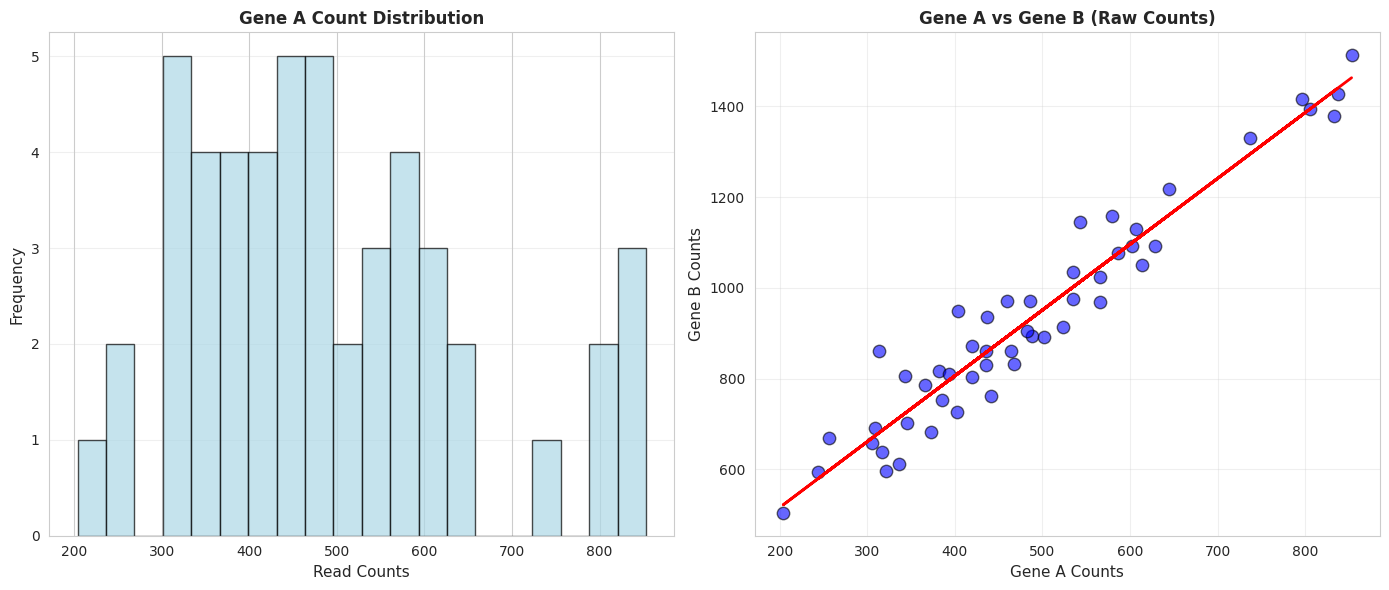


Correlation on RNA-seq counts:
Pearson r: 0.964
Spearman ρ: 0.943

💡 For count data:
   → Distribution is right-skewed (not normal)
   → Spearman is more appropriate
   → Or log-transform first, then use Pearson


In [ ]:
# Generate realistic RNA-seq count data (negative binomial)
np.random.seed(222)
n = 50

# Negative binomial is more realistic for count data
gene_A_counts = np.random.negative_binomial(10, 0.02, n)
gene_B_counts = (gene_A_counts * 1.5 + np.random.negative_binomial(10, 0.05, n)).astype(int)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram shows non-normal distribution
axes[0].hist(gene_A_counts, bins=20, color='lightblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Gene A Count Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Read Counts', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')

# Scatter plot
axes[1].scatter(gene_A_counts, gene_B_counts, alpha=0.6, s=80,
                color='blue', edgecolors='black')
z = np.polyfit(gene_A_counts, gene_B_counts, 1)
p = np.poly1d(z)
axes[1].plot(gene_A_counts, p(gene_A_counts), "r-", linewidth=2)
axes[1].set_title('Gene A vs Gene B (Raw Counts)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Gene A Counts', fontsize=11)
axes[1].set_ylabel('Gene B Counts', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate both correlations
pearson_counts, _ = pearsonr(gene_A_counts, gene_B_counts)
spearman_counts, _ = spearmanr(gene_A_counts, gene_B_counts)

print("\nCorrelation on RNA-seq counts:")
print("="*40)
print(f"Pearson r: {pearson_counts:.3f}")
print(f"Spearman ρ: {spearman_counts:.3f}\n")

print("💡 For count data:")
print("   → Distribution is right-skewed (not normal)")
print("   → Spearman is more appropriate")
print("   → Or log-transform first, then use Pearson")

### Compare with Log-Transformed Data

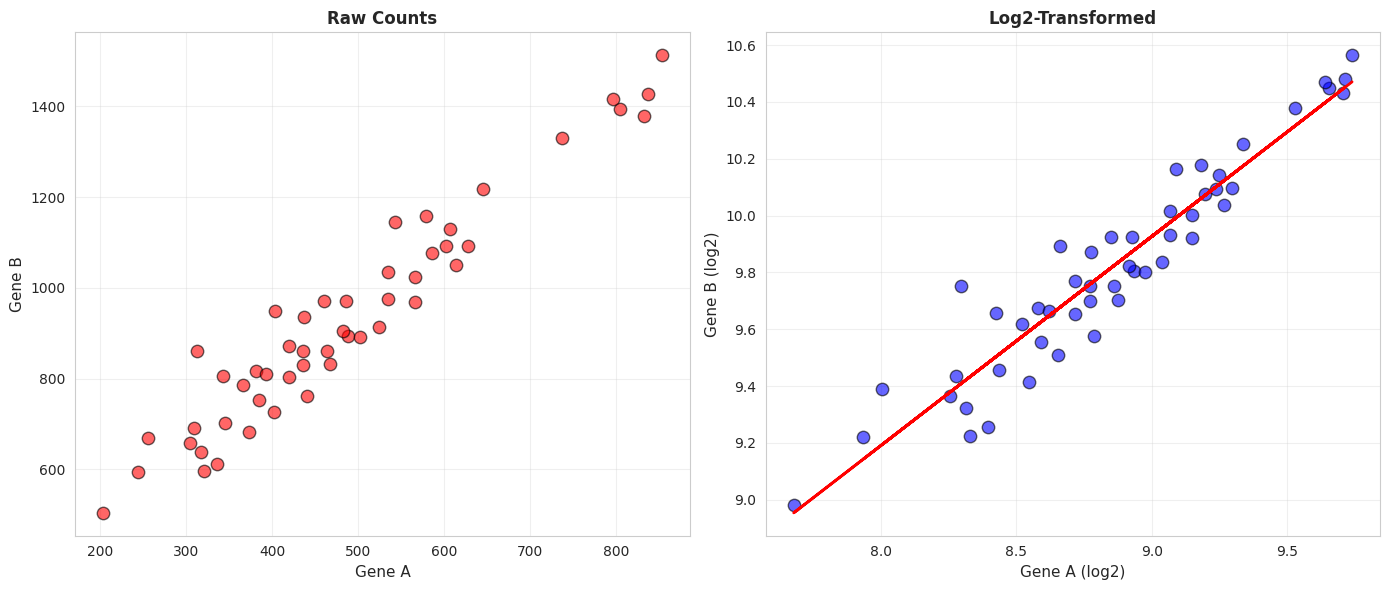


After log transformation:
   Pearson r: 0.951
   → Relationship looks more linear
   → Pearson now appropriate


In [ ]:
# Log-transform (add pseudocount to avoid log(0))
gene_A_log = np.log2(gene_A_counts + 1)
gene_B_log = np.log2(gene_B_counts + 1)

# Visualize transformation effect
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Raw counts
axes[0].scatter(gene_A_counts, gene_B_counts, alpha=0.6, s=80,
                color='red', edgecolors='black')
axes[0].set_title('Raw Counts', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Gene A', fontsize=11)
axes[0].set_ylabel('Gene B', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Log-transformed
axes[1].scatter(gene_A_log, gene_B_log, alpha=0.6, s=80,
                color='blue', edgecolors='black')
z = np.polyfit(gene_A_log, gene_B_log, 1)
p = np.poly1d(z)
axes[1].plot(gene_A_log, p(gene_A_log), "r-", linewidth=2)
axes[1].set_title('Log2-Transformed', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Gene A (log2)', fontsize=11)
axes[1].set_ylabel('Gene B (log2)', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

pearson_log, _ = pearsonr(gene_A_log, gene_B_log)

print("\nAfter log transformation:")
print(f"   Pearson r: {pearson_log:.3f}")
print("   → Relationship looks more linear")
print("   → Pearson now appropriate")

---

## Part 6: Statistical Testing

In [ ]:
# Perform correlation tests
print("\n=== Pearson Correlation Test ===")
r_pearson, p_pearson = pearsonr(data['BDNF'], data['NTRK2'])

# Calculate confidence interval (using Fisher z-transformation)
z = np.arctanh(r_pearson)
se = 1 / np.sqrt(len(data) - 3)
z_crit = 1.96  # 95% CI
ci_lower = np.tanh(z - z_crit * se)
ci_upper = np.tanh(z + z_crit * se)

print(f"\nCorrelation: r = {r_pearson:.3f}")
print(f"P-value: {p_pearson:.6e}")
print(f"95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]")
print(f"Sample size: n = {len(data)}")

if p_pearson < 0.001:
    print("\n→ Highly significant correlation (p < 0.001)")
elif p_pearson < 0.05:
    print("\n→ Significant correlation (p < 0.05)")
else:
    print("\n→ Not significant (p ≥ 0.05)")

print("\n=== Spearman Correlation Test ===")
rho_spearman, p_spearman = spearmanr(data['BDNF'], data['NTRK2'])

print(f"\nCorrelation: ρ = {rho_spearman:.3f}")
print(f"P-value: {p_spearman:.6e}")
print(f"Sample size: n = {len(data)}")

if p_spearman < 0.001:
    print("\n→ Highly significant correlation (p < 0.001)")
elif p_spearman < 0.05:
    print("\n→ Significant correlation (p < 0.05)")
else:
    print("\n→ Not significant (p ≥ 0.05)")


=== Pearson Correlation Test ===

Correlation: r = 0.831
P-value: 8.140522e-14
95% CI: [0.719, 0.901]
Sample size: n = 50

→ Highly significant correlation (p < 0.001)

=== Spearman Correlation Test ===

Correlation: ρ = 0.801
P-value: 2.942140e-12
Sample size: n = 50

→ Highly significant correlation (p < 0.001)


### Understanding the Results

**Statistic:**
- Pearson: t-statistic (tests if r ≠ 0)
- Spearman: Based on rank differences

**Correlation coefficient:**
- Range: -1 to +1
- Sign: positive or negative relationship
- Magnitude: strength of relationship

**P-value:**
- Tests H₀: correlation = 0 (no relationship)
- Small p-value → reject H₀ → significant correlation

**⚠️ CRITICAL: Do NOT use arbitrary cutoffs like "r > 0.7 is strong"!**

The meaning depends on your biological context!

---

## Part 7: Why You Should NOT Use Correlation Cutoffs

### The Problem with "0.3 ≤ |r| < 0.5 → Moderate"

In [ ]:
print("\n⚠️ AVOID These Arbitrary Rules:")
print("="*50)

print("\n❌ DON'T use rules like:")
print("   • |r| < 0.3 → weak")
print("   • 0.3 ≤ |r| < 0.7 → moderate")
print("   • |r| ≥ 0.7 → strong\n")

print("Why? Because correlation strength is CONTEXT-DEPENDENT:\n")

print("Example 1: Gene expression vs protein expression")
print("   • r = 0.4 might be GOOD")
print("   • Why? Post-transcriptional regulation")
print("   • Translation control, protein stability")
print("   • Perfect correlation (r=1) would be surprising!\n")

print("Example 2: Technical replicates")
print("   • r = 0.85 might be POOR")
print("   • Why? Should be > 0.95")
print("   • Same sample, measured twice")
print("   • Low correlation suggests technical problems\n")

print("Example 3: Twin studies (genetic similarity)")
print("   • r = 0.6 for height is EXPECTED")
print("   • Genetics + environment both matter\n")

print("Example 4: Environmental confounders")
print("   • r = 0.9 might be SPURIOUS")
print("   • Both driven by batch effect")
print("   • Not biologically meaningful\n")

print("✓ INSTEAD, ask:")
print("   1. Does the scatter plot show a clear pattern?")
print("   2. Is this correlation biologically meaningful?")
print("   3. What is expected in my system?")
print("   4. Are there potential confounders?")


⚠️ AVOID These Arbitrary Rules:

❌ DON'T use rules like:
   • |r| < 0.3 → weak
   • 0.3 ≤ |r| < 0.7 → moderate
   • |r| ≥ 0.7 → strong

Why? Because correlation strength is CONTEXT-DEPENDENT:

Example 1: Gene expression vs protein expression
   • r = 0.4 might be GOOD
   • Why? Post-transcriptional regulation
   • Translation control, protein stability
   • Perfect correlation (r=1) would be surprising!

Example 2: Technical replicates
   • r = 0.85 might be POOR
   • Why? Should be > 0.95
   • Same sample, measured twice
   • Low correlation suggests technical problems

Example 3: Twin studies (genetic similarity)
   • r = 0.6 for height is EXPECTED
   • Genetics + environment both matter

Example 4: Environmental confounders
   • r = 0.9 might be SPURIOUS
   • Both driven by batch effect
   • Not biologically meaningful

✓ INSTEAD, ask:
   1. Does the scatter plot show a clear pattern?
   2. Is this correlation biologically meaningful?
   3. What is expected in my system?
   4. Are 

### Demonstrate with Examples

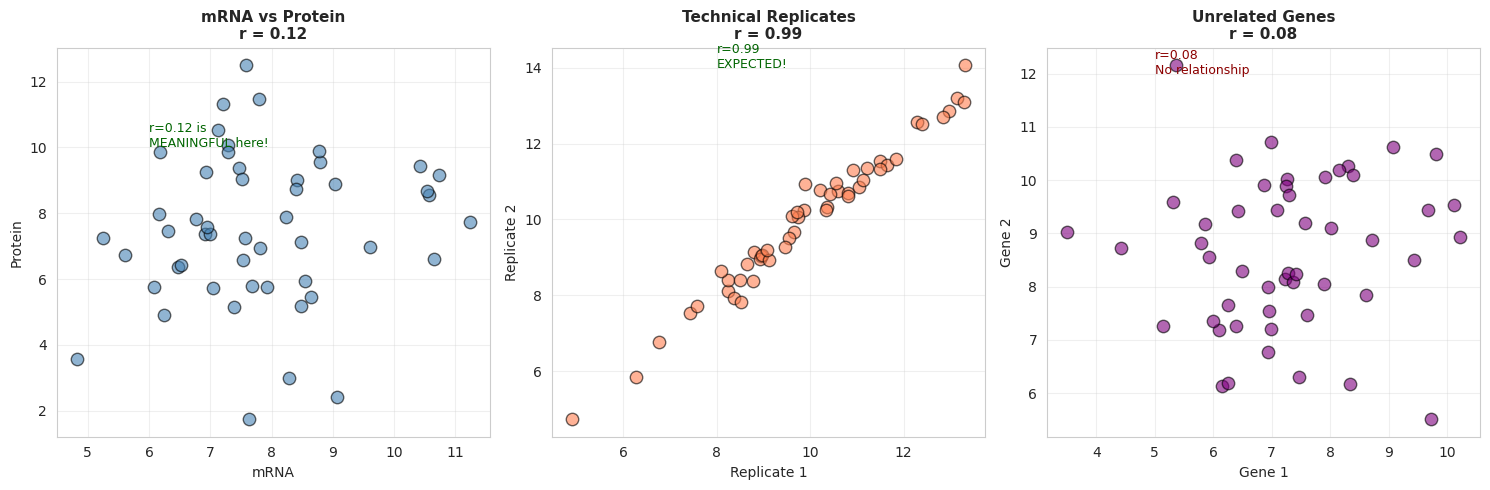


💡 Same correlation value can mean different things!
   → Always interpret in biological context
   → Look at the scatter plot
   → Consider what's expected in your system


In [ ]:
# Generate different scenarios
np.random.seed(333)
n = 50

# Scenario 1: mRNA vs Protein (moderate r, but meaningful)
mRNA = np.random.normal(8, 1.5, n)
protein = mRNA * 0.3 + np.random.normal(5, 2, n)  # Weak linear + lots of noise
r_mrna_protein, _ = pearsonr(mRNA, protein)

# Scenario 2: Technical replicates (high r expected)
replicate1 = np.random.normal(10, 2, n)
replicate2 = replicate1 + np.random.normal(0, 0.3, n)  # Very similar
r_technical, _ = pearsonr(replicate1, replicate2)

# Scenario 3: Two unrelated genes (low r, as expected)
gene_unrelated1 = np.random.normal(7, 1.5, n)
gene_unrelated2 = np.random.normal(9, 1.5, n)
r_unrelated, _ = pearsonr(gene_unrelated1, gene_unrelated2)

# Plot all three
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1
axes[0].scatter(mRNA, protein, alpha=0.6, s=80, color='steelblue', edgecolors='black')
axes[0].set_title(f'mRNA vs Protein\nr = {r_mrna_protein:.2f}',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('mRNA', fontsize=10)
axes[0].set_ylabel('Protein', fontsize=10)
axes[0].text(6, 10, f'r={r_mrna_protein:.2f} is\nMEANINGFUL here!',
             color='darkgreen', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Plot 2
axes[1].scatter(replicate1, replicate2, alpha=0.6, s=80, color='coral', edgecolors='black')
axes[1].set_title(f'Technical Replicates\nr = {r_technical:.2f}',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Replicate 1', fontsize=10)
axes[1].set_ylabel('Replicate 2', fontsize=10)
axes[1].text(8, 14, f'r={r_technical:.2f}\nEXPECTED!',
             color='darkgreen', fontsize=9)
axes[1].grid(True, alpha=0.3)

# Plot 3
axes[2].scatter(gene_unrelated1, gene_unrelated2, alpha=0.6, s=80,
                color='purple', edgecolors='black')
axes[2].set_title(f'Unrelated Genes\nr = {r_unrelated:.2f}',
                  fontsize=11, fontweight='bold')
axes[2].set_xlabel('Gene 1', fontsize=10)
axes[2].set_ylabel('Gene 2', fontsize=10)
axes[2].text(5, 12, f'r={r_unrelated:.2f}\nNo relationship',
             color='darkred', fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Same correlation value can mean different things!")
print("   → Always interpret in biological context")
print("   → Look at the scatter plot")
print("   → Consider what's expected in your system")

---

## Part 8: Correlation ≠ Causation

**Most important concept in this chapter!**

### Example: Confounding Variable

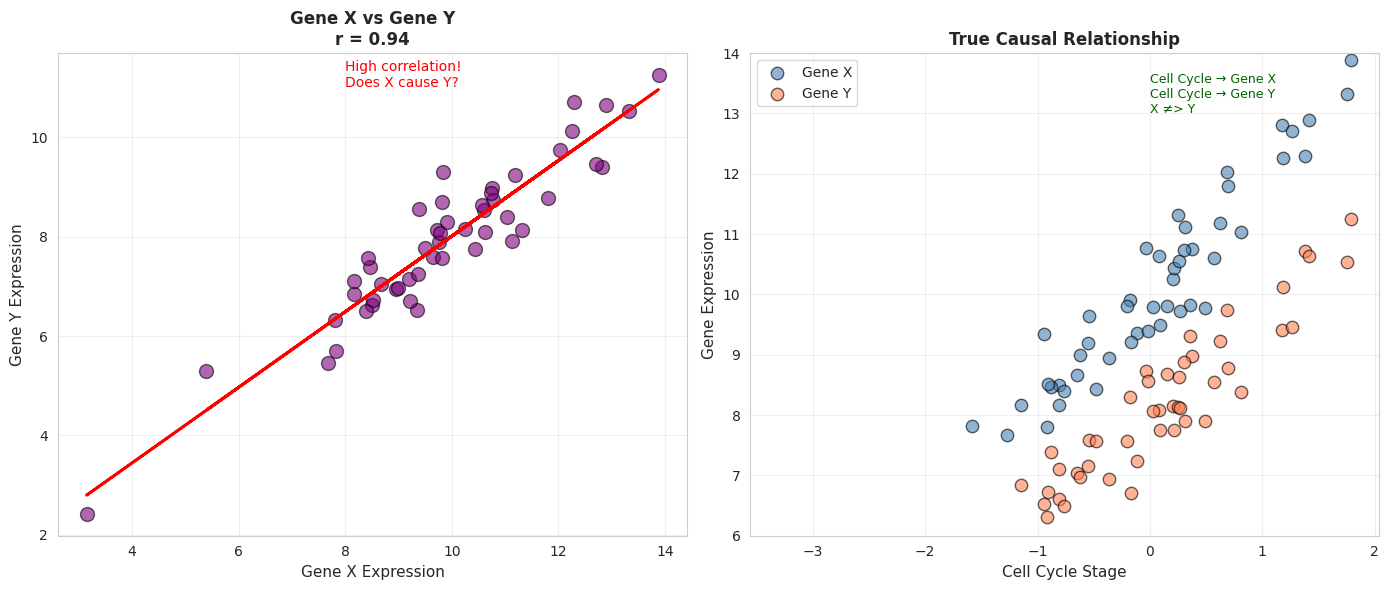


⚠️ Correlation can be misleading!

What we see: Gene X and Y are correlated (r = 0.94)

What we might think: X regulates Y (or Y regulates X)

What's actually happening:
   Cell Cycle → Gene X
   Cell Cycle → Gene Y
   X and Y don't directly interact!

This is called CONFOUNDING


In [ ]:
# Create data with confounding
np.random.seed(444)
n_conf = 50

# Hidden confounder: cell cycle stage
cell_cycle = np.random.normal(0, 1, n_conf)

# Two genes BOTH driven by cell cycle (but don't affect each other)
gene_X = 10 + cell_cycle * 2 + np.random.normal(0, 0.5, n_conf)
gene_Y = 8 + cell_cycle * 1.5 + np.random.normal(0, 0.5, n_conf)

# Calculate correlation
r_confounded, _ = pearsonr(gene_X, gene_Y)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Shows correlation between X and Y
axes[0].scatter(gene_X, gene_Y, alpha=0.6, s=100, color='purple', edgecolors='black')
z = np.polyfit(gene_X, gene_Y, 1)
p = np.poly1d(z)
axes[0].plot(gene_X, p(gene_X), "r-", linewidth=2)
axes[0].set_title(f'Gene X vs Gene Y\nr = {r_confounded:.2f}',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Gene X Expression', fontsize=11)
axes[0].set_ylabel('Gene Y Expression', fontsize=11)
axes[0].text(8, 11, 'High correlation!\nDoes X cause Y?',
             color='red', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Panel 2: Shows true driver
axes[1].scatter(cell_cycle, gene_X, alpha=0.6, s=80, color='steelblue',
                edgecolors='black', label='Gene X')
axes[1].scatter(cell_cycle, gene_Y, alpha=0.6, s=80, color='coral',
                edgecolors='black', label='Gene Y')
axes[1].set_title('True Causal Relationship', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cell Cycle Stage', fontsize=11)
axes[1].set_ylabel('Gene Expression', fontsize=11)
axes[1].set_ylim(6, 14)
axes[1].legend()
axes[1].text(0, 13, 'Cell Cycle → Gene X\nCell Cycle → Gene Y\nX ≠> Y',
             color='darkgreen', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n⚠️ Correlation can be misleading!")
print("="*50)

print(f"\nWhat we see: Gene X and Y are correlated (r = {r_confounded:.2f})\n")

print("What we might think: X regulates Y (or Y regulates X)\n")

print("What's actually happening:")
print("   Cell Cycle → Gene X")
print("   Cell Cycle → Gene Y")
print("   X and Y don't directly interact!\n")

print("This is called CONFOUNDING")

### Common Confounders in Omics

In [ ]:
print("\nCommon Confounders in Genomics:")
print("="*50)

print("\n1. BATCH EFFECTS")
print("   • Different sequencing runs")
print("   • Different days")
print("   → Genes correlate by processing, not biology\n")

print("2. CELL TYPE COMPOSITION")
print("   • Brain: neuron/glia ratio varies")
print("   • Tumor: immune infiltration")
print("   → Cell type markers correlate\n")

print("3. BIOLOGICAL PROCESSES")
print("   • Cell cycle")
print("   • Developmental stage")
print("   • Circadian rhythm")
print("   → Many genes follow same process\n")

print("4. TECHNICAL ARTIFACTS")
print("   • RNA quality")
print("   • Library size")
print("   • Sequencing depth")
print("   → Technical, not biological correlation\n")

print("To establish causation, you need:")
print("   • Perturbation experiments (knockout, overexpression)")
print("   • Time-series (cause must precede effect)")
print("   • Mechanistic validation")


Common Confounders in Genomics:

1. BATCH EFFECTS
   • Different sequencing runs
   • Different days
   → Genes correlate by processing, not biology

2. CELL TYPE COMPOSITION
   • Brain: neuron/glia ratio varies
   • Tumor: immune infiltration
   → Cell type markers correlate

3. BIOLOGICAL PROCESSES
   • Cell cycle
   • Developmental stage
   • Circadian rhythm
   → Many genes follow same process

4. TECHNICAL ARTIFACTS
   • RNA quality
   • Library size
   • Sequencing depth
   → Technical, not biological correlation

To establish causation, you need:
   • Perturbation experiments (knockout, overexpression)
   • Time-series (cause must precede effect)
   • Mechanistic validation


---

## Part 9: Correlation Matrix and Heatmap

**Analyzing multiple genes at once**

In [ ]:
# Generate multi-gene dataset
np.random.seed(555)
n_samples = 50

# Create 3 modules
# Module 1: Neuronal (genes 1-3)
neuronal = np.random.normal(0, 2, n_samples)
gene1 = 8 + neuronal + np.random.normal(0, 0.5, n_samples)
gene2 = 7.5 + neuronal * 0.9 + np.random.normal(0, 0.5, n_samples)
gene3 = 9 + neuronal * 0.85 + np.random.normal(0, 0.6, n_samples)

# Module 2: Immune (genes 4-6)
immune = np.random.normal(0, 1.5, n_samples)
gene4 = 10 + immune + np.random.normal(0, 0.8, n_samples)
gene5 = 9.5 + immune * 0.7 + np.random.normal(0, 0.8, n_samples)
gene6 = 11 + immune * 0.6 + np.random.normal(0, 0.9, n_samples)

# Module 3: Independent
gene7 = np.random.normal(12, 1.5, n_samples)
gene8 = np.random.normal(11, 1.5, n_samples)

# Create DataFrame
expr_matrix = pd.DataFrame({
    'BDNF': gene1,
    'NTRK2': gene2,
    'SYN1': gene3,
    'IL6': gene4,
    'TNF': gene5,
    'IFNG': gene6,
    'ACTB': gene7,
    'GAPDH': gene8
})

# Calculate correlation matrix
cor_matrix = expr_matrix.corr(method='pearson')

print("\nCorrelation Matrix:")
print(cor_matrix.round(2))


Correlation Matrix:
       BDNF  NTRK2  SYN1   IL6   TNF  IFNG  ACTB  GAPDH
BDNF   1.00   0.93  0.93  0.08 -0.07  0.02 -0.33   0.02
NTRK2  0.93   1.00  0.92  0.07 -0.15  0.01 -0.23  -0.05
SYN1   0.93   0.92  1.00 -0.04 -0.19 -0.02 -0.29  -0.01
IL6    0.08   0.07 -0.04  1.00  0.68  0.55 -0.14   0.13
TNF   -0.07  -0.15 -0.19  0.68  1.00  0.43 -0.08   0.10
IFNG   0.02   0.01 -0.02  0.55  0.43  1.00 -0.12  -0.13
ACTB  -0.33  -0.23 -0.29 -0.14 -0.08 -0.12  1.00   0.07
GAPDH  0.02  -0.05 -0.01  0.13  0.10 -0.13  0.07   1.00


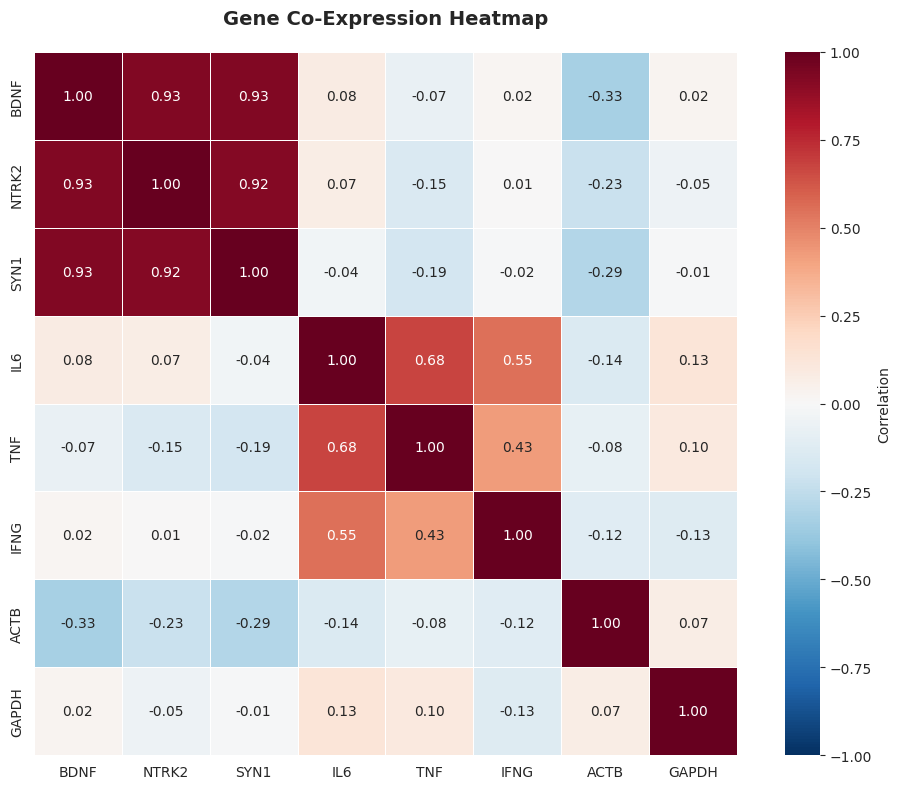


💡 Interpreting the heatmap:
   • Red: Positive correlation
   • Blue: Negative correlation
   • White: No correlation
   • Darker colors = stronger correlation

Biological interpretation:
   • Module 1 (BDNF, NTRK2, SYN1): Neuronal genes - highly correlated
   • Module 2 (IL6, TNF, IFNG): Immune genes - moderately correlated
   • Module 3 (ACTB, GAPDH): Housekeeping - independent


In [ ]:
# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cor_matrix,
            annot=True,  # Show correlation values
            fmt='.2f',   # Format to 2 decimal places
            cmap='RdBu_r',  # Red-Blue colormap (reversed)
            center=0,    # Center colormap at 0
            vmin=-1, vmax=1,  # Set color limits
            square=True,  # Make cells square
            linewidths=0.5,  # Add gridlines
            cbar_kws={'label': 'Correlation'})

plt.title('Gene Co-Expression Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n💡 Interpreting the heatmap:")
print("   • Red: Positive correlation")
print("   • Blue: Negative correlation")
print("   • White: No correlation")
print("   • Darker colors = stronger correlation\n")

print("Biological interpretation:")
print("   • Module 1 (BDNF, NTRK2, SYN1): Neuronal genes - highly correlated")
print("   • Module 2 (IL6, TNF, IFNG): Immune genes - moderately correlated")
print("   • Module 3 (ACTB, GAPDH): Housekeeping - independent")

---

## Summary

### Key Takeaways

✓ **ALWAYS plot first** (descriptive statistics)
  - Scatter plots reveal relationship type
  - Show outliers and non-linearity
  - More informative than correlation numbers

✓ **Choosing the right method:**
  - **Pearson:** Linear relationships, clean data
  - **Spearman:** Monotonic relationships, outliers, count data
  - When in doubt → use Spearman (safer)

✓ **Avoid arbitrary cutoffs**
  - No universal "r > 0.7 = strong" rule
  - Interpret in biological context
  - Consider what's expected in your system

✓ **Correlation ≠ Causation**
  - High correlation doesn't mean X causes Y
  - Always consider confounders
  - Need experiments for causation

✓ **Report properly:**
  - State method used (Pearson or Spearman) and why
  - Include: r (or ρ), p-value, sample size
  - Show scatter plot
  - Discuss biological meaning

### Decision Flowchart Summary

```
1. Make scatter plot
   ↓
2. Linear + No outliers? → Pearson
   Non-linear or Outliers? → Spearman
   ↓
3. Calculate correlation
   ↓
4. Check p-value
   ↓
5. Interpret in biological context
   (NOT by arbitrary cutoffs!)
   ↓
6. Consider confounders
   ↓
7. Design experiments if claiming causation
```

---

## Practice Exercise

**Scenario:** You have proteomics and metabolomics data from the same samples.

**Tasks:**
1. Generate data for enzyme expression and its metabolic product
2. Create scatter plot
3. Decide: Pearson or Spearman?
4. Calculate correlation and test significance
5. Add one outlier - how does it affect results?
6. Compare Pearson vs Spearman with outlier
7. Can you claim the enzyme causes the metabolite level?

In [ ]:
# YOUR CODE HERE
# Hint: Follow the workflow above

# 1. Generate data
np.random.seed(777)
# enzyme = ...
# metabolite = ...

# 2. Scatter plot

# 3. Choose method

# 4. Calculate correlation

# 5. Add outlier

# 6. Compare methods

# 7. Discuss causation


---

## References

- Pearson, K. (1895). "Note on Regression and Inheritance in the Case of Two Parents." Proceedings of the Royal Society of London 58:240-242
- Spearman, C. (1904). "The Proof and Measurement of Association between Two Things." The American Journal of Psychology 15(1):72-101